In [ ]:
#!wget https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv

--2026-10-04 18:23:15--  https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 635180 (620K) [text/plain]
Saving to: ‘car_fuel_efficiency_2026.csv.1’

car_fuel_efficiency 100%[===================>] 620.29K  --.-KB/s    in 0.01s   

2026-10-04 18:23:15 (60.1 MB/s) - ‘car_fuel_efficiency_2026.csv.1’ saved [635180/635180]



## 0. Preparation

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [11]:
df = pd.read_csv("car_fuel_efficiency_2026.csv")
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


## 1. Missing values

In [12]:
df = df.drop(columns=["origin", "fuel_type", "drivetrain", "num_doors", "num_cylinders", "acceleration"])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   model_year           10000 non-null  int64  
 1   engine_displacement  10000 non-null  int64  
 2   horsepower           9123 non-null   float64
 3   vehicle_weight       10000 non-null  int64  
 4   fuel_efficiency_mpg  10000 non-null  float64
dtypes: float64(2), int64(3)
memory usage: 390.8 KB


<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

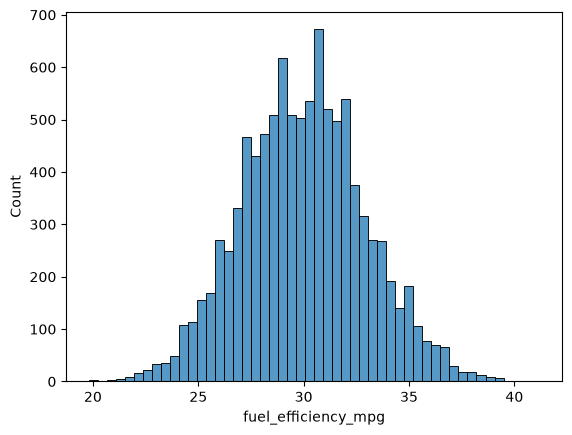

In [13]:
sns.histplot(df.fuel_efficiency_mpg, bins=50)

## 2. Median for horsepower

In [34]:
df['horsepower'].median()

np.float64(254.0)

## 3. Filling NAs

In [ ]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]

In [23]:
def dot(xi, w):
    n = len(xi)

    res = 0.0

    for j in range(n):
        res = res + xi[j] * w[j]

    return res

def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [ ]:
base = ["model_year", "engine_displacement", "horsepower", "vehicle_weight"]
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values

### Filling with 0

In [55]:
df_train_zeros = df_train.fillna(0)
df_val_zeros = df_val.fillna(0)
w0, w = train_linear_regression(df_train_zeros[base], y_train)

zero_y_pred = w0 + df_val_zeros[base].dot(w)
zero_rmse = rmse(y_val, zero_y_pred)

print(zero_rmse)

2.2070365928224294


### Filling with mean

In [56]:
mean_hp = df_train['horsepower'].mean()
df_train_mean = df_train.fillna(mean_hp)
df_val_mean = df_val.fillna(mean_hp)
w0, w = train_linear_regression(df_train_mean[base], y_train)

mean_y_pred = w0 + df_val_mean[base].dot(w)
mean_rmse = rmse(y_val, mean_y_pred)

print(mean_rmse)

2.207338747849128


<Axes: ylabel='Count'>

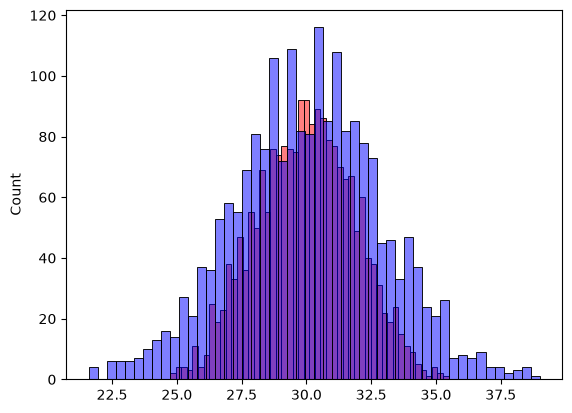

In [59]:
sns.histplot(zero_y_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_val, color='blue', alpha=0.5, bins=50)

<Axes: ylabel='Count'>

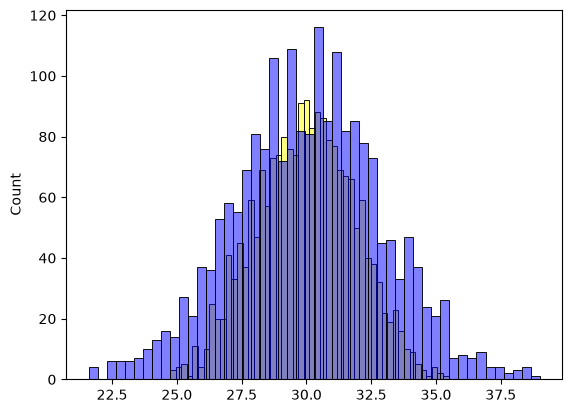

In [58]:
sns.histplot(mean_y_pred, color='yellow', alpha=0.5, bins=50)
sns.histplot(y_val, color='blue', alpha=0.5, bins=50)

## 4. Regularization

In [35]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [63]:
r_list = [0, 0.01, 0.1, 1, 5, 10, 100]

for r in r_list:
    w0, w = train_linear_regression_reg(df_train_zeros[base], y_train, r)

    y_pred = w0 + df_val_zeros[base].dot(w)
    print(f'r: {r}, rmse: {round(rmse(y_val, y_pred), 4)}')

r: 0, rmse: 2.207
r: 0.01, rmse: 2.2067
r: 0.1, rmse: 2.2195
r: 1, rmse: 2.3364
r: 5, rmse: 2.3952
r: 10, rmse: 2.4051
r: 100, rmse: 2.4146


## 5. RMSE standard deviation

In [62]:
seed_list = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
rmse_list = []
for seed in seed_list:
    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_train = df_train.fillna(0)
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_val = df_val.fillna(0)

    y_train = df_train.fuel_efficiency_mpg.values
    y_val = df_val.fuel_efficiency_mpg.values
    
    w0, w = train_linear_regression(df_train[base], y_train)

    zero_y_pred = w0 + df_val[base].dot(w)
    zero_rmse = rmse(y_val, zero_y_pred)

    print(zero_rmse)
    rmse_list.append(zero_rmse)

print(f"standard deviation: {round(np.std(rmse_list), 3)}")

2.2392041430501806
2.202112821083673
2.163419778753099
2.2043588768533473
2.20188009433277
2.24578515090842
2.269721207951272
2.190794599934713
2.216611201694147
2.2070365928224294
standard deviation: 0.029


## 6. Evaluation on test

In [67]:
np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df = df.fillna(0)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

X_combined = pd.concat([df_train, df_val], axis=0)

y_combined = X_combined.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

w0, w = train_linear_regression_reg(X_combined[base], y_combined, r=0.001)
print(w0, w)

y_pred = w0 + df_test[base].dot(w)
model_rmse = rmse(y_test, y_pred)

print(round(model_rmse, 3))

-152.3753577246596 [ 0.10140402 -0.00135534 -0.00042645 -0.00401765]
2.236
